In [2]:
#INSTALLING SEABORN

import micropip
await micropip.install('seaborn')

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [4]:
burn_out = pd.read_csv("developer_burnout_dataset_7000.csv")
burn_out.head(6)

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low
5,40.0,2.0,10.25,6.78,0.0,19.0,27.0,4.0,15.15,0.78,51.06,Medium


In [5]:
burn_out.describe() 

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level
count,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000,6860.000000
mean,32.129446,9.581050,9.000277,6.485638,3.540671,9.482653,14.458455,4.545044,11.974773,1.007611,53.652825
std,7.230254,5.760972,2.863944,1.445008,2.283445,5.751664,8.669846,2.856766,3.091204,0.576708,23.446656
min,20.000000,0.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,5.210000,0.000000,0.000000
25%,26.000000,5.000000,6.560000,5.220000,2.000000,5.000000,7.000000,2.000000,9.460000,0.510000,36.587500
50%,32.000000,10.000000,8.990000,6.460000,4.000000,9.000000,14.000000,5.000000,12.020000,1.020000,53.795000
75%,38.000000,15.000000,11.422500,7.740000,6.000000,14.000000,22.000000,7.000000,14.422500,1.510000,70.800000
max,44.000000,19.000000,14.000000,9.000000,7.000000,19.000000,29.000000,9.000000,18.930000,2.000000,100.000000


In [6]:
burn_out.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 629.0+ KB


In [7]:
burn_out.isnull().sum()

age                 140
experience_years    140
daily_work_hours    140
sleep_hours         140
caffeine_intake     140
bugs_per_day        140
commits_per_day     140
meetings_per_day    140
screen_time         140
exercise_hours      140
stress_level        140
burnout_level       140
dtype: int64

In [8]:
(burn_out==0).sum()

age                   0
experience_years    346
daily_work_hours      0
sleep_hours           0
caffeine_intake     824
bugs_per_day        336
commits_per_day     220
meetings_per_day    662
screen_time           0
exercise_hours       20
stress_level         77
burnout_level         0
dtype: int64

In [9]:
# Drop rows where the target (burnout_level) is missing
burn_out = burn_out.dropna(subset=['burnout_level'])

In [10]:
# Fill missing numerical values with median to avoid errors
numeric_cols = burn_out.select_dtypes(include=[np.number]).columns
burn_out[numeric_cols] = burn_out[numeric_cols].fillna(burn_out[numeric_cols].median())


In [13]:
 #MAPPING THE TARGET
# Transforming text categories into numbers for the model
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
burn_out['burnout_level'] = burn_out['burnout_level'].map(target_mapping)

In [14]:
burn_out.head()

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,1
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,2
2,34.0,13.0,8.98,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,1
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,1
4,27.0,7.0,4.24,5.80,4.0,9.0,17.0,7.0,8.05,0.36,27.90,0


In [16]:
 #FEATURE ENGINEERING (Added for better accuracy)
burn_out['work_recovery_ratio'] = burn_out['daily_work_hours'] / (burn_out['sleep_hours'] + 1)
burn_out['meeting_load'] = burn_out['meetings_per_day'] * burn_out['daily_work_hours']

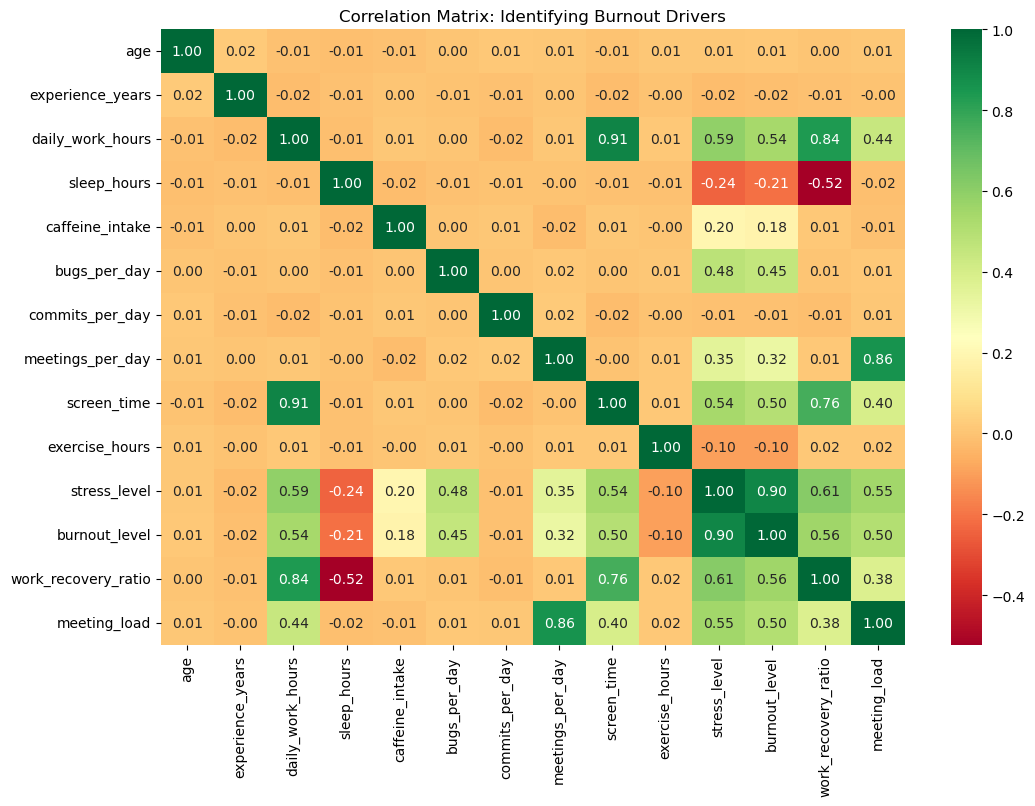

In [18]:
 #CORRELATION & HEATMAP
plt.figure(figsize=(12, 8))
correlation_matrix = burn_out.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title("Correlation Matrix: Identifying Burnout Drivers")
plt.show()

In [27]:
#SPLIT THE DATA
# Features (X) and Target (y)
X = burn_out.drop(columns=['burnout_level', 'stress_level'])
y = burn_out['burnout_level']

# Training set (80%) and Test set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
#MODEL TRAINING & TESTING
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# Accuracy Testing
y_pred = model.predict(X_test)
print(f"Overall Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred))

Overall Accuracy Score: 77.55%

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75       326
           1       0.75      0.83      0.79       705
           2       0.81      0.71      0.76       341

    accuracy                           0.78      1372
   macro avg       0.79      0.75      0.77      1372
weighted avg       0.78      0.78      0.77      1372



In [30]:
 #SAVE FOR DEPLOYMENT (Roadmap Phase 2)
joblib.dump(model, 'burnout_model.pkl')
print("Model saved successfully as 'burnout_model.pkl'")

Model saved successfully as 'burnout_model.pkl'
